# NBA Player Statistics – Exploratory Data Analysis

## Introduction
This project explores an NBA player statistics dataset containing player information across multiple seasons. The goal of the project is to understand the structure of the data, summarize important variables, create visualizations, and add team-level information through a join. I chose this dataset because sports data is familiar, interesting, and useful for practicing exploratory data analysis.

## Dataset Source
The main dataset used in this project is `all_seasons.csv`, which contains NBA player information and seasonal statistics. A second dataset, `team_lookup.csv`, was manually created to add conference and division information using the `team_abbreviation` field.

## What the Dataset Contains
The dataset includes player names, team abbreviations, age, height, weight, college, country, draft information, season, and statistics such as points, rebounds, and assists. Each row represents a player-season record.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/all_seasons.csv")
joined_df = pd.read_csv("../clean_data/nba_players_with_team_info.csv")

## Join Explanation

The join itself was completed in a separate Python script, where the main NBA dataset (`all_seasons.csv`) was merged with a second dataset (`team_lookup.csv`) using `team_abbreviation` as the key. That process created a new file called `nba_players_with_team_info.csv`, which is loaded in this notebook as `joined_df`.

I used a left merge because the NBA player dataset is the main dataset, and I wanted to keep every player-season record while adding conference and division information where a match existed.

This type of merge can create missing values in the new columns if a team abbreviation does not match between the two datasets.

In [14]:
team_lookup = pd.read_csv("../data/team_lookup.csv")
team_lookup.head()

,team_abbreviation,conference,division
0,ATL,Eastern,Southeast
1,BOS,Eastern,Atlantic
2,BKN,Eastern,Atlantic
3,CHA,Eastern,Southeast
4,CHI,Eastern,Central


In [15]:
joined_check = pd.merge(
    df,
    team_lookup,
    how="left",
    on="team_abbreviation"
)

joined_check[["team_abbreviation", "conference", "division"]].head()

,team_abbreviation,conference,division
0,HOU,Western,Southwest
1,WAS,Eastern,Southeast
2,VAN,NaN,NaN
3,LAL,Western,Pacific
4,DEN,Western,Northwest


In [11]:
df.head()
joined_df.head()

,Unnamed: 0,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,...,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season,conference,division
0,0,Randy Livingston,HOU,22.0,193.04,94.800728,Louisiana State,USA,1996,2,...,2.4,0.3,0.042,0.071,0.169,0.487,0.248,1996-97,Western,Southwest
1,1,Gaylon Nickerson,WAS,28.0,190.50,86.182480,Northwestern Oklahoma,USA,1994,2,...,0.3,8.9,0.030,0.111,0.174,0.497,0.043,1996-97,Eastern,Southeast
2,2,George Lynch,VAN,26.0,203.20,103.418976,North Carolina,USA,1993,1,...,1.9,-8.2,0.106,0.185,0.175,0.512,0.125,1996-97,NaN,NaN
3,3,George McCloud,LAL,30.0,203.20,102.058200,Florida State,USA,1989,1,...,1.7,-2.7,0.027,0.111,0.206,0.527,0.125,1996-97,Western,Pacific
4,4,George Zidek,DEN,23.0,213.36,119.748288,UCLA,USA,1995,1,...,0.3,-14.1,0.102,0.169,0.195,0.500,0.064,1996-97,Western,Northwest


This confirms how the join works directly in the notebook. The main dataset is merged with the team lookup table using `team_abbreviation`, which adds conference and division columns.

In [16]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nInfo:")
df.info()

print("\nSummary statistics:")
display(df.describe())

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False))

Shape: (12844, 22)

Columns:
['Unnamed: 0', 'player_name', 'team_abbreviation', 'age', 'player_height', 'player_weight', 'college', 'country', 'draft_year', 'draft_round', 'draft_number', 'gp', 'pts', 'reb', 'ast', 'net_rating', 'oreb_pct', 'dreb_pct', 'usg_pct', 'ts_pct', 'ast_pct', 'season']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12844 entries, 0 to 12843
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         12844 non-null  int64  
 1   player_name        12844 non-null  object 
 2   team_abbreviation  12844 non-null  object 
 3   age                12844 non-null  float64
 4   player_height      12844 non-null  float64
 5   player_weight      12844 non-null  float64
 6   college            10990 non-null  object 
 7   country            12844 non-null  object 
 8   draft_year         12844 non-null  object 
 9   draft_round        12844 non-null  object 
 10  draft_nu

,Unnamed: 0,age,player_height,player_weight,gp,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct
count,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000
mean,6421.500000,27.045313,200.555097,100.263279,51.154158,8.212582,3.558486,1.824681,-2.226339,0.054073,0.140646,0.184641,0.513138,0.131595
std,3707.887763,4.339211,9.111090,12.426628,25.084904,6.016573,2.477885,1.800840,12.665124,0.043335,0.062513,0.053545,0.101724,0.094172
min,0.000000,18.000000,160.020000,60.327736,1.000000,0.000000,0.000000,0.000000,-250.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3210.750000,24.000000,193.040000,90.718400,31.000000,3.600000,1.800000,0.600000,-6.400000,0.021000,0.096000,0.149000,0.482000,0.066000
50%,6421.500000,26.000000,200.660000,99.790240,57.000000,6.700000,3.000000,1.200000,-1.300000,0.040000,0.130500,0.181000,0.525000,0.103000
75%,9632.250000,30.000000,208.280000,108.862080,73.000000,11.500000,4.700000,2.400000,3.200000,0.083000,0.179000,0.217000,0.563000,0.179000
max,12843.000000,44.000000,231.140000,163.293120,85.000000,36.100000,16.300000,11.700000,300.000000,1.000000,1.000000,1.000000,1.500000,1.000000



Missing values:


college              1854
Unnamed: 0              0
pts                     0
ast_pct                 0
ts_pct                  0
usg_pct                 0
dreb_pct                0
oreb_pct                0
net_rating              0
ast                     0
reb                     0
gp                      0
player_name             0
draft_number            0
draft_round             0
draft_year              0
country                 0
player_weight           0
player_height           0
age                     0
team_abbreviation       0
season                  0
dtype: int64

## Initial Inspection and Descriptive Analysis

To begin the analysis, I inspected the shape of the dataset, reviewed the columns, checked for missing values, and created summary statistics. This helps establish what kind of data is available and what patterns can be explored further through visualization.

In [28]:
df.isna().sum().sort_values(ascending=False).head(15)

college         1854
Unnamed: 0         0
pts                0
ast_pct            0
ts_pct             0
usg_pct            0
dreb_pct           0
oreb_pct           0
net_rating         0
ast                0
reb                0
gp                 0
player_name        0
draft_number       0
draft_round        0
dtype: int64

In [32]:
df["season"].nunique(), df["season"].min(), df["season"].max()

(27, '1996-97', '2022-23')

In [28]:
df.sort_values("reb", ascending=False)[["player_name","season","team_abbreviation","pts","reb","ast"]].head(10)

,player_name,season,team_abbreviation,pts,reb,ast
2070,Danny Fortson,2000-01,GSW,16.7,16.3,0.8
188,Dennis Rodman,1996-97,CHI,5.7,16.1,3.1
9907,Andre Drummond,2017-18,DET,15.0,16.0,3.0
10286,Andre Drummond,2018-19,DET,17.3,15.6,1.4
2948,Ben Wallace,2002-03,DET,6.9,15.4,1.6
9885,DeAndre Jordan,2017-18,LAC,12.0,15.2,1.5
6292,Kevin Love,2010-11,MIN,20.2,15.2,2.5
10855,Andre Drummond,2019-20,CLE,17.7,15.2,2.7
760,Dennis Rodman,1997-98,CHI,4.7,15.0,2.9
8446,DeAndre Jordan,2014-15,LAC,11.5,15.0,0.7


In [45]:
df.sort_values("pts", ascending=True)[["player_name","season","team_abbreviation","pts","reb","ast"]].head(10)

,player_name,season,team_abbreviation,pts,reb,ast
6802,Hamady Ndiaye,2011-12,WAS,0.0,0.0,0.0
4235,Nene,2005-06,DEN,0.0,0.0,0.0
12048,Nate Hinton,2021-22,IND,0.0,0.0,0.0
2659,Pepe Sanchez,2002-03,DET,0.0,0.7,0.9
12095,M.J. Walker,2021-22,PHX,0.0,0.5,0.5
2675,Paul Shirley,2002-03,ATL,0.0,0.5,0.0
9855,Chris Boucher,2017-18,GSW,0.0,1.0,0.0
5624,Martell Webster,2008-09,POR,0.0,0.0,0.0
4195,Randy Livingston,2005-06,CHI,0.0,0.8,0.2
12145,Matt Mooney,2021-22,NYK,0.0,0.0,0.0


In [33]:
df[df["pts"] > 23.7][["player_name", "season", "team_abbreviation", "pts", "reb", "ast"]].sort_values("pts", ascending=True)

,player_name,season,team_abbreviation,pts,reb,ast
12692,Kawhi Leonard,2022-23,LAC,23.8,6.5,3.9
11325,Brandon Ingram,2020-21,NOP,23.8,4.9,4.9
8303,Stephen Curry,2014-15,GSW,23.8,4.3,7.7
10136,Donovan Mitchell,2018-19,UTA,23.8,4.1,4.2
12315,Paul George,2022-23,LAC,23.8,6.1,5.1
...,...,...,...,...,...,...
4302,Allen Iverson,2005-06,PHI,33.0,3.2,7.4
12839,Joel Embiid,2022-23,PHI,33.1,10.2,4.2
10634,James Harden,2019-20,HOU,34.3,6.6,7.5
4163,Kobe Bryant,2005-06,LAL,35.4,5.3,4.5


In [36]:
df[(df["pts"] > 22.4) & (df["reb"] > 5.3)][["player_name", "season", "team_abbreviation", "pts", "reb", "ast"]].sort_values("pts", ascending=True)

,player_name,season,team_abbreviation,pts,reb,ast
6520,Blake Griffin,2010-11,LAC,22.5,12.1,3.8
1413,Kobe Bryant,1999-00,LAL,22.5,6.3,4.9
11029,Zion Williamson,2019-20,NOP,22.5,6.3,2.1
4275,Chris Bosh,2005-06,TOR,22.5,9.2,2.6
1320,Michael Finley,1999-00,DAL,22.6,6.3,5.3
...,...,...,...,...,...,...
2847,Tracy McGrady,2002-03,ORL,32.1,6.5,5.5
12740,Luka Doncic,2022-23,DAL,32.4,8.6,8.0
12839,Joel Embiid,2022-23,PHI,33.1,10.2,4.2
10634,James Harden,2019-20,HOU,34.3,6.6,7.5


In [44]:
df.groupby("season")["pts"].mean()

season
1996-97    8.026077
1997-98    7.947608
1998-99    7.358542
1999-00    7.985845
2000-01    7.811338
2001-02    7.982727
2002-03    7.849299
2003-04    7.745475
2004-05    8.088147
2005-06    7.982533
2006-07    8.208734
2007-08    8.267184
2008-09    8.503820
2009-10    8.571719
2010-11    8.206195
2011-12    7.928870
2012-13    7.957996
2013-14    8.090249
2014-15    8.122561
2015-16    8.349370
2016-17    8.426749
2017-18    8.160370
2018-19    8.613585
2019-20    8.726465
2020-21    8.942407
2021-22    8.240000
2022-23    9.121336
Name: pts, dtype: float64

## Research Questions

This project is guided by the following questions:

1. What does the distribution of scoring look like across all player-season records?
2. How has average scoring changed across NBA seasons?
3. Is there a relationship between player usage percentage and scoring output?
4. What additional insight can be gained by joining team-level conference and division information?

In [18]:
missing_summary = df.isna().sum().reset_index()
missing_summary.columns = ["column", "missing_values"]
missing_summary = missing_summary.sort_values("missing_values", ascending=False)
missing_summary.head(15)

,column,missing_values
6,college,1854
0,Unnamed: 0,0
12,pts,0
20,ast_pct,0
19,ts_pct,0
18,usg_pct,0
17,dreb_pct,0
16,oreb_pct,0
15,net_rating,0
14,ast,0


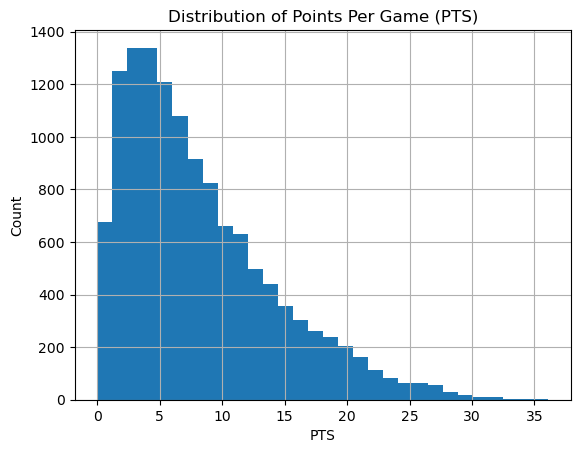

In [5]:
import matplotlib.pyplot as plt

df["pts"].hist(bins=30)
plt.title("Distribution of Points Per Game (PTS)")
plt.xlabel("PTS")
plt.ylabel("Count")
plt.show()

### Interpretation of Points Distribution

This histogram shows the distribution of points per game across all player-season records in the dataset. Most observations are concentrated at the lower end of the scoring range, with fewer players averaging very high point totals. This creates a right-skewed distribution, which makes sense because only a small number of players score at an elite level, while many players have lower scoring averages.

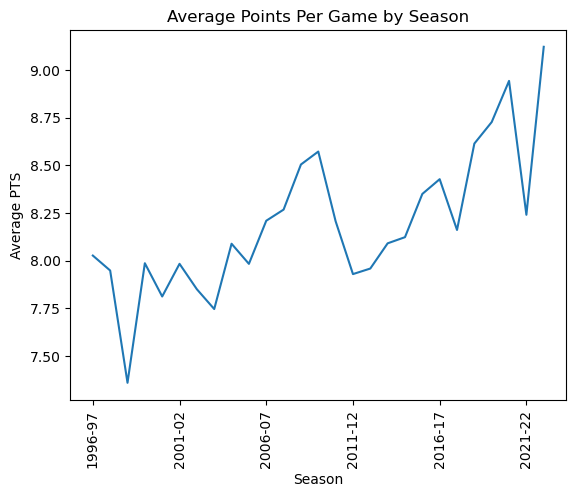

In [6]:
avg_pts_by_season = df.groupby("season")["pts"].mean().sort_index()

avg_pts_by_season.plot()
plt.title("Average Points Per Game by Season")
plt.xlabel("Season")
plt.ylabel("Average PTS")
plt.xticks(rotation=90)
plt.show()

### Interpretation of Average Points by Season

This graph shows how the average points per game in the dataset changes across NBA seasons. While the values do not rise perfectly every year, the overall pattern suggests that average scoring tends to increase over time. This is useful because it shows that player scoring trends are not static and that season-level analysis can reveal broader changes in the game.

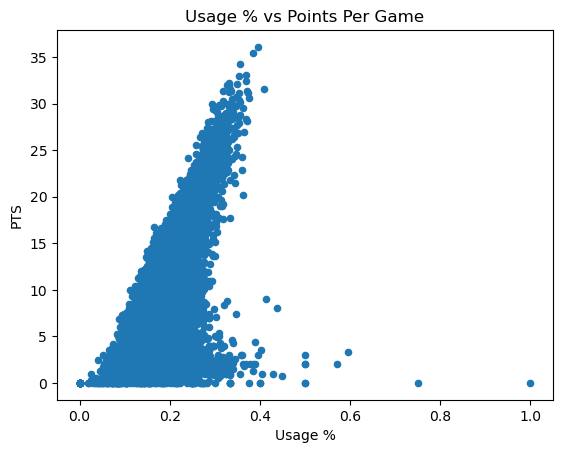

In [7]:
df.plot(kind="scatter", x="usg_pct", y="pts")
plt.title("Usage % vs Points Per Game")
plt.xlabel("Usage %")
plt.ylabel("PTS")
plt.show()

### Interpretation of Usage % vs Points Per Game

This scatterplot compares player usage percentage with points per game. There is a clear positive relationship, meaning that players with higher usage percentages generally tend to score more points. However, the relationship is not perfect, since some players have moderate or even high usage without scoring at the same level. This graph is important because it shows that offensive role and scoring are related, but other factors also affect production.

In [19]:
joined_df[["team_abbreviation", "conference", "division"]].head(10)
joined_df["conference"].value_counts()
joined_df.groupby("conference")["pts"].mean().round(2)
joined_df.groupby("division")["pts"].mean().round(2).sort_values(ascending=False)

division
Pacific      8.56
Northwest    8.25
Southwest    8.22
Central      8.16
Atlantic     8.14
Southeast    8.09
Name: pts, dtype: float64

In [21]:
division_avg_points = joined_df.groupby("division")["pts"].mean().round(2).sort_values(ascending=False)
division_avg_points

division
Pacific      8.56
Northwest    8.25
Southwest    8.22
Central      8.16
Atlantic     8.14
Southeast    8.09
Name: pts, dtype: float64

In [22]:
division_avg_points = (
    joined_df.groupby("division")["pts"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
)

division_avg_points.columns = ["division", "average_points"]
division_avg_points

,division,average_points
0,Pacific,8.56
1,Northwest,8.25
2,Southwest,8.22
3,Central,8.16
4,Atlantic,8.14
5,Southeast,8.09


This table shows the average points per game across all player-season records in each division. Because it includes every type of player-season entry, including lower-scoring and lower-usage players, the averages are much lower than star-player scoring averages. The Pacific division has the highest overall average in this dataset at 8.56 points per game.

In [23]:
top_10_by_division = (
    joined_df.sort_values(["division", "pts"], ascending=[True, False])
    .groupby("division")
    .head(10)
)

division_top10_avg = (
    top_10_by_division.groupby("division")["pts"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
)

division_top10_avg.columns = ["division", "average_points_top_10"]
division_top10_avg

,division,average_points_top_10
0,Atlantic,30.75
1,Pacific,30.65
2,Southwest,30.46
3,Northwest,30.14
4,Central,29.81
5,Southeast,29.52


This table shows the average points per game for the top 10 scoring player-season records in each division. This gives a different perspective than averaging all players, because it focuses on the highest-scoring performers in each division. That makes it easier to compare where the strongest offensive player-seasons are concentrated.

In [27]:
highest_scorer_by_division = (
    joined_df.sort_values("pts", ascending=False)
    .groupby("division")
    .head(2)[["division", "player_name", "season", "team_abbreviation", "pts"]]
    .sort_values("pts", ascending=False)
    .reset_index(drop=True)
)

highest_scorer_by_division

,division,player_name,season,team_abbreviation,pts
0,Southwest,James Harden,2018-19,HOU,36.1
1,Pacific,Kobe Bryant,2005-06,LAL,35.4
2,Southwest,James Harden,2019-20,HOU,34.3
3,Atlantic,Joel Embiid,2022-23,PHI,33.1
4,Atlantic,Allen Iverson,2005-06,PHI,33.0
5,Northwest,Damian Lillard,2022-23,POR,32.2
6,Southeast,Tracy McGrady,2002-03,ORL,32.1
7,Pacific,Stephen Curry,2020-21,GSW,32.0
8,Northwest,Kevin Durant,2013-14,OKC,32.0
9,Central,LeBron James,2005-06,CLE,31.4


In [37]:
missing_summary = df.isna().sum().reset_index()
missing_summary.columns = ["column", "missing_values"]
missing_summary = missing_summary.sort_values("missing_values", ascending=False)

top_scorers = df[df["pts"] > 20][
    ["player_name", "season", "team_abbreviation", "pts", "reb", "ast"]
].sort_values("pts", ascending=False)

conference_summary = joined_df.groupby("conference").agg(
    player_season_records=("player_name", "count"),
    avg_points=("pts", "mean"),
    avg_rebounds=("reb", "mean"),
    avg_assists=("ast", "mean")
).round(2)

division_summary = joined_df.groupby("division").agg(
    player_season_records=("player_name", "count"),
    avg_points=("pts", "mean")
).round(2).sort_values("avg_points", ascending=False)

season_scoring_summary = df.groupby("season").agg(
    avg_points=("pts", "mean"),
    avg_rebounds=("reb", "mean"),
    avg_assists=("ast", "mean")
).round(2)

In [38]:
missing_summary.to_csv("../results/missing_values_summary.csv", index=False)
top_scorers.to_csv("../results/top_scorers.csv", index=False)
conference_summary.to_csv("../results/conference_summary.csv")
division_summary.to_csv("../results/division_summary.csv")
season_scoring_summary.to_csv("../results/season_scoring_summary.csv")

In [40]:
conference_avg_points = (
    joined_df.groupby("conference")["pts"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
)

conference_avg_points.columns = ["conference", "average_points"]
conference_avg_points

,conference,average_points
0,Western,8.35
1,Eastern,8.13


This table shows the average points per game by conference after the join. It demonstrates that the joined dataset can now be grouped at a broader level than the original player dataset alone, which makes the analysis more flexible and informative.